# Full Pipeline Runner (Notebook)

This notebook runs the full CLI pipeline and then visualizes training results.

Pipeline stages:
1. Preprocessing
2. Keyframe extraction
3. Landmark extraction
4. Training

Split note:
- Current project training uses **train/validation split only** (default 80/20).
- There is **no separate test split** in the current trainer script by default.
- This notebook includes an optional holdout-test evaluation cell.

In [4]:
from pathlib import Path
import subprocess
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'pyproject.toml').exists():
    # If notebook opens from a different cwd, force project root using this file path.
    project_root = Path('H:/Projects/sem-5-ml-project')

sys.path.insert(0, str(project_root))

pipeline_script = project_root / 'util_scripts' / 'run_full_pipeline.py'
trainer_script = project_root / 'model' / 'trainer_current_config-gpu.py'

dataset_dir = project_root / 'dataset' / 'raw_video_data'
preprocessed_dir = project_root / 'outputs' / 'preprocessed'
keyframes_dir = project_root / 'outputs' / 'keyframes'
landmarks_dir = project_root / 'outputs' / 'landmarks'
checkpoint_dir = project_root / 'checkpoints' / 'lstm_run1'

print('Project root    :', project_root)
print('Pipeline script :', pipeline_script)
print('Trainer script  :', trainer_script)
print('Checkpoint dir  :', checkpoint_dir)

Project root    : H:\Projects\sem-5-ml-project
Pipeline script : H:\Projects\sem-5-ml-project\util_scripts\run_full_pipeline.py
Trainer script  : H:\Projects\sem-5-ml-project\model\trainer_current_config-gpu.py
Checkpoint dir  : H:\Projects\sem-5-ml-project\checkpoints\lstm_run1


## 1) Dataset Validator\n\nQuick check before running the pipeline:\n- Validates expected class folders\n- Counts videos per class\n- Reports missing or extra label folders\n- Warns if class folders exist but are empty

In [2]:
expected_labels = [
    'brother', 'call', 'drink', 'go', 'help',
    'man', 'mother', 'no', 'short', 'tall',
    'what', 'who', 'why', 'woman', 'yes',
]

video_exts = {'.mp4', '.avi', '.mov', '.mkv'}

if not dataset_dir.exists():
    raise FileNotFoundError(f'Dataset directory not found: {dataset_dir}')

label_dirs = sorted([p for p in dataset_dir.iterdir() if p.is_dir()])
found_labels = [p.name for p in label_dirs]

missing_labels = sorted(set(expected_labels) - set(found_labels))
extra_labels = sorted(set(found_labels) - set(expected_labels))

counts = {}
total_videos = 0
empty_classes = []

for label_dir in label_dirs:
    files = [
        p for p in label_dir.iterdir()
        if p.is_file() and p.suffix.lower() in video_exts
    ]
    counts[label_dir.name] = len(files)
    total_videos += len(files)
    if len(files) == 0:
        empty_classes.append(label_dir.name)

print('Dataset root      :', dataset_dir)
print('Total label dirs  :', len(found_labels))
print('Total videos      :', total_videos)
print()

print('Per-class video counts:')
for label in sorted(counts):
    print(f'  {label:10s} -> {counts[label]}')

print()
print('Missing expected labels:', missing_labels if missing_labels else 'None')
print('Extra labels          :', extra_labels if extra_labels else 'None')
print('Empty label folders   :', empty_classes if empty_classes else 'None')

is_valid = (len(missing_labels) == 0) and (len(empty_classes) == 0)
print()
print('Dataset validation status:', 'PASS' if is_valid else 'CHECK REQUIRED')

import pandas as pd
summary_df = pd.DataFrame([
    {'label': label, 'video_count': counts.get(label, 0)}
    for label in sorted(set(expected_labels) | set(found_labels))
]).sort_values(['video_count', 'label'], ascending=[False, True]).reset_index(drop=True)
summary_df

Dataset root      : H:\Projects\sem-5-ml-project\dataset\raw_video_data
Total label dirs  : 15
Total videos      : 187

Per-class video counts:
  brother    -> 11
  call       -> 12
  drink      -> 15
  go         -> 15
  help       -> 14
  man        -> 12
  mother     -> 11
  no         -> 11
  short      -> 13
  tall       -> 13
  what       -> 12
  who        -> 14
  why        -> 11
  woman      -> 11
  yes        -> 12

Missing expected labels: None
Extra labels          : None
Empty label folders   : None

Dataset validation status: PASS


,label,video_count
0,drink,15
1,go,15
2,help,14
3,who,14
4,short,13
5,tall,13
6,call,12
7,man,12
8,what,12
9,yes,12


## 2) Run Full Pipeline\n\nSet `RUN_PIPELINE = True` to execute all stages.\n\nTip: For quick checks, add one or more skip flags in `cmd` below, for example `--skip-preprocessing` and `--skip-keyframes`.

In [9]:
RUN_PIPELINE = True

cmd = [
    sys.executable,
    str(pipeline_script),
    '--dataset-dir', str(dataset_dir.relative_to(project_root)),
    '--preprocessed-dir', str(preprocessed_dir.relative_to(project_root)),
    '--keyframes-dir', str(keyframes_dir.relative_to(project_root)),
    '--landmarks-dir', str(landmarks_dir.relative_to(project_root)),
    '--checkpoint-dir', str(checkpoint_dir.relative_to(project_root)),
    '--trainer-script', str(trainer_script.relative_to(project_root)),
    '--model-type', 'lstm',
    '--batch-size', '8',
    '--num-epochs', '50',
    '--device', 'cuda',
    '--num-workers', '4',
    '--use-mixed-precision',
    '--grad-accum-steps', '2',
]

if RUN_PIPELINE:
    result = subprocess.run(cmd, cwd=project_root, check=False)
    print('Exit code:', result.returncode)
else:
    print('RUN_PIPELINE is False. Set it to True to run training from this notebook.')
    print(' '.join(cmd))

Exit code: 1


## 3) Confirm Current Split Behavior\n\nCurrent training loader creates:\n- Train split: 80%\n- Validation split: 20%\n- Test split: not created by default

In [7]:
try:
    from model.dataset import SignLanguageDataset, create_data_loaders
except ModuleNotFoundError:
    import sys
    sys.path.insert(0, str(project_root))
    from model.dataset import SignLanguageDataset, create_data_loaders

dataset = SignLanguageDataset(landmarks_dir=landmarks_dir)
train_loader, val_loader = create_data_loaders(
    landmarks_dir=landmarks_dir,
    batch_size=8,
    train_split=0.8,
    random_seed=42,
)

print('Total samples:', len(dataset))
print('Train samples:', len(train_loader.dataset))
print('Val samples  :', len(val_loader.dataset))
print('Test samples : 0 (not used by default trainer)')

Loaded 187 samples from 15 classes
Loaded 187 samples from 15 classes
Created data loaders:
  Train: 149 samples
  Val: 38 samples
  Batch size: 8
Total samples: 187
Train samples: 149
Val samples  : 38
Test samples : 0 (not used by default trainer)


## 4) Visualize Training Curves\n\nThis reads `training_history.json` from your checkpoint directory.

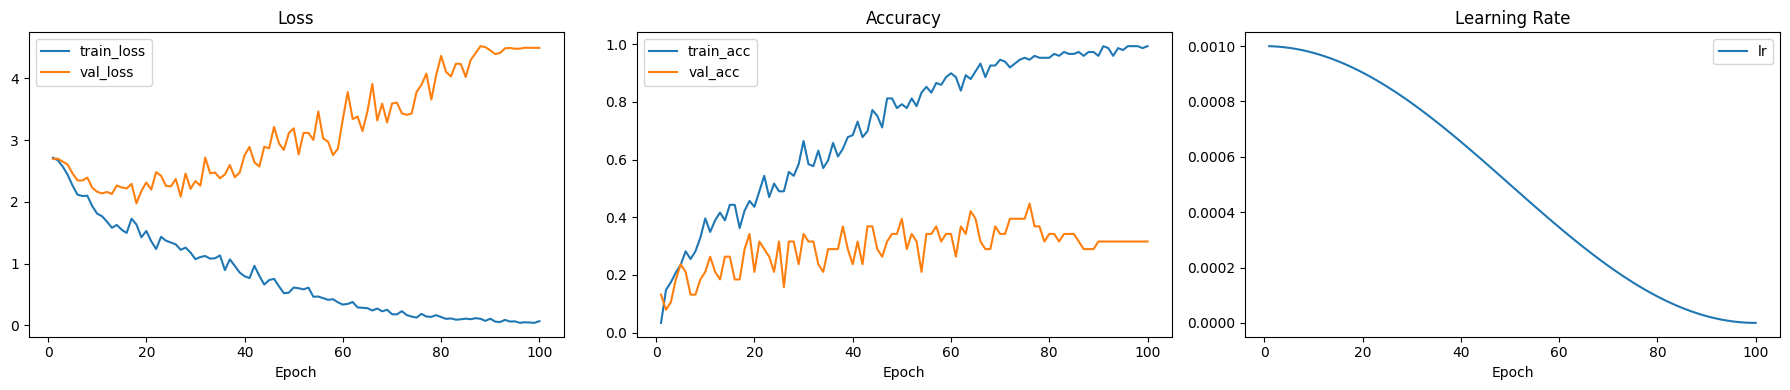

In [10]:
history_path = checkpoint_dir / 'training_history.json'
if not history_path.exists():
    print(f'Training history not found at {history_path}.')
    print('Please run the training pipeline first!')
else:
    with open(history_path, 'r', encoding='utf-8') as f:
        history = json.load(f)

    epochs = range(1, len(history.get('train_loss', [])) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, history.get('train_loss', []), label='train_loss')
    axes[0].plot(epochs, history.get('val_loss', []), label='val_loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history.get('train_acc', []), label='train_acc')
    axes[1].plot(epochs, history.get('val_acc', []), label='val_acc')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    axes[2].plot(epochs, history.get('learning_rates', []), label='lr')
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 5) Validation Confusion Matrix and Metrics\n\nLoads `best_model.pth` and evaluates on validation split.

Created lstm model on cuda
Total parameters: 2,615,567


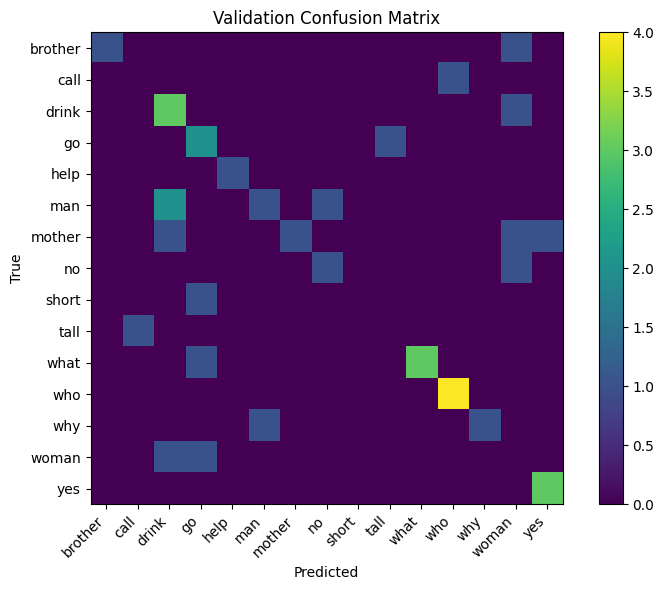

              precision    recall  f1-score   support

     brother       1.00      0.50      0.67         2
        call       0.00      0.00      0.00         1
       drink       0.43      0.75      0.55         4
          go       0.40      0.67      0.50         3
        help       1.00      1.00      1.00         1
         man       0.50      0.25      0.33         4
      mother       1.00      0.25      0.40         4
          no       0.50      0.50      0.50         2
       short       0.00      0.00      0.00         1
        tall       0.00      0.00      0.00         1
        what       1.00      0.75      0.86         4
         who       0.80      1.00      0.89         4
         why       1.00      0.50      0.67         2
       woman       0.00      0.00      0.00         2
         yes       0.75      1.00      0.86         3

    accuracy                           0.55        38
   macro avg       0.56      0.48      0.48        38
weighted avg       0.64   

In [8]:
import torch
from sklearn.metrics import confusion_matrix, classification_report

try:
    from model.sign_classifier import create_model
except ModuleNotFoundError:
    import sys
    sys.path.insert(0, str(project_root))
    from model.sign_classifier import create_model

checkpoint_path = checkpoint_dir / 'best_model.pth'
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Best checkpoint not found: {checkpoint_path}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint = torch.load(checkpoint_path, map_location=device)
cfg = checkpoint.get('config', {})

model_type = cfg.get('model_type', 'lstm')
num_classes = int(cfg.get('num_classes', len(dataset.classes)))
landmark_dim = int(cfg.get('landmark_dim', dataset[0][0].shape[-1]))

model = create_model(
    model_type=model_type,
    num_classes=num_classes,
    device=device,
    landmark_dim=landmark_dim,
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(y.cpu().numpy().tolist())

labels_sorted = dataset.classes
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(labels_sorted))))

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Validation Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(labels_sorted))
plt.xticks(tick_marks, labels_sorted, rotation=45, ha='right')
plt.yticks(tick_marks, labels_sorted)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=labels_sorted, zero_division=0))

## 6) Interactive Error Analysis\n\nInteractive Plotly views for validation results:\n- Confusion-matrix heatmap with hover values\n- Class-wise precision and recall bars

In [9]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Build confusion matrix dataframe for interactive heatmap
cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)

fig_cm = px.imshow(
    cm_df,
    text_auto=True,
    aspect='auto',
    color_continuous_scale='Blues',
    labels={'x': 'Predicted label', 'y': 'True label', 'color': 'Count'},
    title='Validation Confusion Matrix (Interactive)'
)
fig_cm.update_xaxes(side='bottom')
fig_cm.update_layout(width=900, height=700)
fig_cm.show()

# Compute class-wise precision/recall from confusion matrix
cm_float = cm.astype(float)
true_pos = np.diag(cm_float)
pred_totals = cm_float.sum(axis=0)
true_totals = cm_float.sum(axis=1)

precision = np.divide(true_pos, pred_totals, out=np.zeros_like(true_pos), where=pred_totals != 0)
recall = np.divide(true_pos, true_totals, out=np.zeros_like(true_pos), where=true_totals != 0)

metrics_df = pd.DataFrame({
    'class': labels_sorted,
    'precision': precision,
    'recall': recall,
}).sort_values('recall', ascending=False)

fig_bars = go.Figure()
fig_bars.add_trace(go.Bar(
    x=metrics_df['class'],
    y=metrics_df['precision'],
    name='Precision',
    marker_color='#1f77b4'
))
fig_bars.add_trace(go.Bar(
    x=metrics_df['class'],
    y=metrics_df['recall'],
    name='Recall',
    marker_color='#ff7f0e'
))
fig_bars.update_layout(
    title='Class-wise Precision vs Recall (Validation)',
    xaxis_title='Class',
    yaxis_title='Score',
    yaxis=dict(range=[0, 1]),
    barmode='group',
    width=1000,
    height=500
)
fig_bars.show()

metrics_df

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 7) Optional Test Split Evaluation\n\nUse this if you want a separate test holdout right now without changing project trainer code.

In [ ]:
from torch.utils.data import random_split, DataLoader

RUN_TEST_EVAL = False
if RUN_TEST_EVAL:
    full_dataset = SignLanguageDataset(landmarks_dir=landmarks_dir)
    n = len(full_dataset)
    n_train = max(1, int(0.7 * n))
    n_val = max(1, int(0.15 * n))
    n_test = n - n_train - n_val
    if n_test < 1:
        n_test = 1
        n_val = max(1, n_val - 1)

    gen = torch.Generator().manual_seed(42)
    train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=gen)

    test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

    test_preds, test_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            test_preds.extend(preds.cpu().numpy().tolist())
            test_labels.extend(y.cpu().numpy().tolist())

    print('Split sizes -> train:', n_train, 'val:', n_val, 'test:', n_test)
    print(classification_report(test_labels, test_preds, target_names=full_dataset.classes, zero_division=0))
else:
    print('RUN_TEST_EVAL is False. Set it to True to run holdout test evaluation.')